# Taft Plot Investigations

This workbook contains the code and imports the data to explore how Taft used acid and base-catalyzed ester hydrolysis to develope the taft steric and electronic parameters.

## Plot $pK_a$ vs $\sigma$

Plot $pK_a$ vs $\sigma$ to confirm that Taft $\sigma^*$ values track with Hammett $\sigma$ values. The slope should be near one if the substituent parameters were scaled propertly (recall that taft used the Hammett $\rho$ value of 2.3 when setting his $\sigma^*$ values so we will multiply all $\sigma$ values used by 2.3 in this plot.) 

In [10]:
####################################################
### Import Libraries and set up global variables ###
####################################################

# Install packages only if needed
# Coogle Colab does not include every Python package
#   
try:                  # if the package exists import it, otherwise install it
    import lmfit
except ImportError:
    !pip -q install lmfit
    import lmfit

try:
    import uncertainties
except ImportError:
    !pip -q install uncertainties
    import uncertainties

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import linregress
from scipy.optimize import curve_fit

import uncertainties as un
from uncertainties import unumpy as unp

from matplotlib.ticker import FormatStrFormatter
from scipy.stats import t

from pathlib import Path

Path("plots").mkdir(exist_ok=True)
#Path("data").mkdir(exist_ok=True)

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

#if IN_COLAB and not Path("data/3c.csv").exists():
#    !wget -q -O data/3c.csv https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/notebooks/M11_Plot_Recommendations/3c.csv

if IN_COLAB and not Path("tufte.mplstyle").exists():
    !wget -q https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/styles/tufte.mplstyle
if IN_COLAB and not Path("data").exists():
    !wget -q https://raw.github.com/blinkletter/Chem4410Webbook/main/book/notebooks/M15_Handout_Comments/data.zip
    !unzip -q data.zip


github_location_LFER_tables = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/data/"

plt.rcdefaults()

#################################################################
### Global Variable                                           ###
#################################################################

sigmatype = "s_plus"    # change to "sigma", "s_plus", or "s_minus"


###################################################################
### a function to fill in sigma for empty spaces in s+ and s-   ###
###################################################################

def fill_sigma(df):     
    for z in df.index:
        if np.isnan(df.loc[z,"s_plus"]):
            df.loc[z,"s_plus"] = df.loc[z,"sigma"]
        if np.isnan(df["s_minus"][z]):
            df.loc[z,"s_minus"] = df.loc[z,"sigma"]
    return(df)


################################################################################
### Read data set. The fields are separated by commas; comments are enabled  ###
################################################################################

#LFER_file = "LFER_HanschLeoTaft.csv"
LFER_file = "LFER_Williams.csv"

data_set = pd.read_csv(github_location_LFER_tables + LFER_file,
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent",   
                 comment = "#") 


########################################################
### Fill across sigma values and select substituents ###
########################################################

data_set=fill_sigma(data_set)

### Remove unneeded columns
if LFER_file == "LFER_HanschLeoTaft.csv":
    data_set.drop(labels = ["TABLE V", "TABLE I"],      #Trim "LFER_HanschLeoTaft.csv" data
    axis = 1,
    inplace = True)
elif LFER_file == "LFER_Williams.csv":
    data_set.drop(labels = ["Page"],                   #Trim "LFER_Williams.csv"" data
    axis = 1,
    inplace = True)
else:
    print("ERROR: No filename")
print(data_set)

################################################################################
### Read table 1 data. The fields are separated by commas; comments are enabled  ###
################################################################################

data_file = "data/17-Table_4.csv"

table_data_df = pd.read_csv(data_file,
                 delimiter = ",", 
                 skipinitialspace=True, 
#                 index_col="Substituent",    # Cant use Substituent as index - duplicate entries in data series
                 comment = "#") 

### Join the two dataframes according to the index column (Substituent)
#df = pd.concat([table_data_df, data_set], axis=1, join="inner")

#df.sort_values(by=[sigmatype], inplace=True)    # sort according to sigma so we can pick the left-most and right-most points more easily

#df["logk"] = np.log10(df["k"])


print(table_data_df)

             sigma  s_plus  s_minus
Substituent                        
m-Br          0.39    0.39     0.39
p-Br          0.23    0.15     0.25
m-C6H5        0.06    0.06     0.06
p-C6H5       -0.01    0.02    -0.18
m-CCCH3       0.10    0.10     0.10
...            ...     ...      ...
p-C(CH3)3    -0.20   -0.26    -0.13
m-C(CH3)3    -0.10   -0.10    -0.10
3,5-CH3      -0.12   -0.12    -0.12
3,4,5-CH3    -0.26   -0.43    -0.29
3,4-CH3      -0.20   -0.37    -0.23

[76 rows x 3 columns]
      Group  Formula  pKa_COOH  pKa_CH2OH Substituent  Number_of_substituents
0        Me      CH3      4.76      16.00           H                     1.0
1     ClCH2    CH2Cl      2.86      14.31        m-Cl                     1.0
2     BrCH2    CH2Br      2.86        NaN        m-Br                     1.0
3     Cl2CH    CHCl2      1.29      12.89        m-Cl                     2.0
4      CCl3     CCl3      0.65      12.24        m-Cl                     3.0
5      CBr3     CBr3      0.66        NaN

In [11]:
##########################################################################
### A little program to copy in the sigma values for each substituent. ###
### Perhaps someday I will make it a proper function for general use.  ###
##########################################################################

# We are doing this because the substituent column contains double entries for many substituents and cannot be used as an index column.

table_data_df.dropna(subset = "Substituent", inplace = True)  # One of the substituents in this dataframe has no value. Drop that row.


table_data_df["sigma"] = np.nan     # Create new columns in the dataframe to reference
table_data_df["s_plus"] = np.nan
table_data_df["s_minus"] = np.nan

for x in table_data_df.index:
    substituent_name = table_data_df["Substituent"][x]   # Get the name of the substituent in row x
#    print(substituent_name)
    sigma_series = data_set.loc[substituent_name]    # get the set of sigma values from the Hammett data

    table_data_df.loc[x, "s_minus"] = sigma_series["s_minus"]  # insert the Hammett parameters
    table_data_df.loc[x, "s_plus"] = sigma_series["s_plus"]
    table_data_df.loc[x, "sigma"] = sigma_series["sigma"]

    
#########################################################################
### Perform calculations on columns and add new columns with results  ###
#########################################################################

display(table_data_df)

,Group,Formula,pKa_COOH,pKa_CH2OH,Substituent,Number_of_substituents,sigma,s_plus,s_minus
0,Me,CH3,4.76,16.00,H,1.0,0.00,0.00,0.00
1,ClCH2,CH2Cl,2.86,14.31,m-Cl,1.0,0.37,0.37,0.37
2,BrCH2,CH2Br,2.86,NaN,m-Br,1.0,0.39,0.39,0.39
3,Cl2CH,CHCl2,1.29,12.89,m-Cl,2.0,0.37,0.37,0.37
4,CCl3,CCl3,0.65,12.24,m-Cl,3.0,0.37,0.37,0.37
5,CBr3,CBr3,0.66,NaN,m-Br,3.0,0.39,0.39,0.39
6,CF3,CF3,0.00,12.37,m-F,3.0,0.34,0.34,0.34
7,FCH2,CH2F,2.66,NaN,m-F,1.0,0.34,0.34,0.34
8,Ph,C6H5,4.31,15.40,m-C6H5,1.0,0.06,0.06,0.06
9,CNCH2,CH2CN,2.43,NaN,m-CN,1.0,0.56,0.56,0.56


In [12]:
### Multiply sigmas for multiple substituents.

table_data_df["sigma"] = table_data_df["sigma"]*table_data_df["Number_of_substituents"]
table_data_df

,Group,Formula,pKa_COOH,pKa_CH2OH,Substituent,Number_of_substituents,sigma,s_plus,s_minus
0,Me,CH3,4.76,16.00,H,1.0,0.00,0.00,0.00
1,ClCH2,CH2Cl,2.86,14.31,m-Cl,1.0,0.37,0.37,0.37
2,BrCH2,CH2Br,2.86,NaN,m-Br,1.0,0.39,0.39,0.39
3,Cl2CH,CHCl2,1.29,12.89,m-Cl,2.0,0.74,0.37,0.37
4,CCl3,CCl3,0.65,12.24,m-Cl,3.0,1.11,0.37,0.37
5,CBr3,CBr3,0.66,NaN,m-Br,3.0,1.17,0.39,0.39
6,CF3,CF3,0.00,12.37,m-F,3.0,1.02,0.34,0.34
7,FCH2,CH2F,2.66,NaN,m-F,1.0,0.34,0.34,0.34
8,Ph,C6H5,4.31,15.40,m-C6H5,1.0,0.06,0.06,0.06
9,CNCH2,CH2CN,2.43,NaN,m-CN,1.0,0.56,0.56,0.56


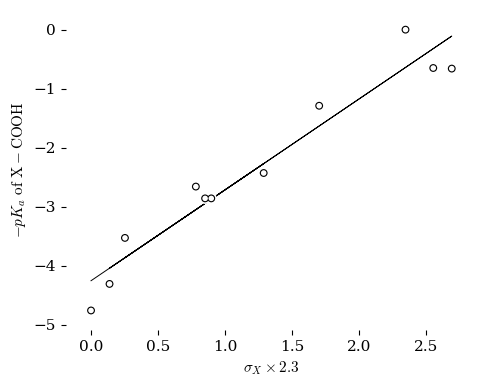

Acid Series (open circles)
slope  = 1.5
intercept = -4.256
RSQ = 0.935
LinregressResult(slope=1.540993631135689, intercept=-4.255905001269358, rvalue=0.9669646632999931, pvalue=1.2082271376084615e-06, stderr=0.13541183807884294, intercept_stderr=0.20835246054881712)


In [13]:

#####################################################
### Get series of data to plot from the dataframe ###
#####################################################

y = -table_data_df["pKa_COOH"]
x =  table_data_df["sigma"]*2.3

from scipy.stats import linregress
import matplotlib

##################################################
### Setup a figure with two plots side-by-side ###
### and choose a stylesheet                    ###
##################################################

style_file = "tufte.mplstyle"
plt.style.use(style_file)        

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   


#########################################
### Plot the data and the line fit.   ###
#########################################

#ax.plot(x, y, color='black', zorder=1, linewidth=0.7)

ax.scatter(x,y, s=64, color="white",  edgecolors = "none", zorder=2)
ax.scatter(x,y, s=32, color="black",  edgecolors = "none", zorder=2)
ax.scatter(x,y, s=16, color="white",  edgecolors = "none", alpha = 1, zorder=2)


if True:   # Flag to run or not. True = run this section, False = skip it
    linfit = linregress(x,y)
    fit = linfit.slope * x + linfit.intercept
    ax.plot(x, fit, color='black', zorder=1, linewidth=0.7)
    



############################
### Set labels and scale ###
############################

ax.set(
#    title="Hammett Plot",       
          ylabel=r"$-pK_a \rm~of~X-COOH$", 
          xlabel=r"$\sigma_X \times 2.3$",                
#          xlim=[-.9,.9],                  
#          ylim=[-6,-1]
         )



if False:    # Flag to run or not. True = run this section, False = skip it
    for name,x_place,y_place in zip(list(df.index),x,y):
        plt.annotate(name, # this is the text
                    (x_place,y_place), # these are the coordinates to position the label
                    textcoords="offset points", # how to position the text
                    xytext=(30,0), # distance from text to points (x,y)
                    ha='left') # horizontal alignment can be left, right or center




fig.savefig("plots/plot.pdf")   # use this to save the figure in PDF format
plt.show()                 # output the combined plot plots

#make_axes_area_auto_adjustable(ax)
#####################################
### Print the line fit parameters ###
#####################################
print("Acid Series (open circles)")
print(f"slope  = {linfit.slope:0.1f}")
print(f"intercept = {linfit.intercept:0.3f}")
print(f"RSQ = {(linfit.rvalue**2):0.3f}")
print(linfit)



   Group Formula  pKa_COOH  pKa_CH2OH Substituent  Number_of_substituents  \
0     Me     CH3      4.76      16.00           H                     1.0   
1  ClCH2   CH2Cl      2.86      14.31        m-Cl                     1.0   
3  Cl2CH   CHCl2      1.29      12.89        m-Cl                     2.0   
4   CCl3    CCl3      0.65      12.24        m-Cl                     3.0   
6    CF3     CF3      0.00      12.37         m-F                     3.0   
8     Ph    C6H5      4.31      15.40      m-C6H5                     1.0   

   sigma  s_plus  s_minus  
0   0.00    0.00     0.00  
1   0.37    0.37     0.37  
3   0.74    0.37     0.37  
4   1.11    0.37     0.37  
6   1.02    0.34     0.34  
8   0.06    0.06     0.06  


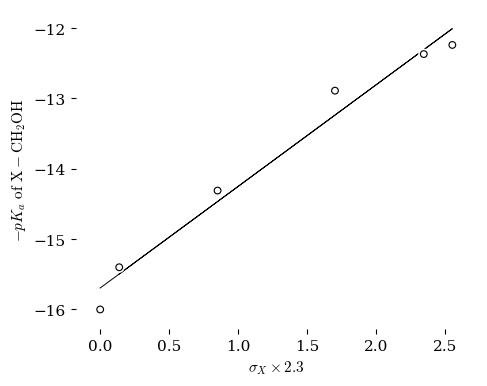

Acid Series (open circles)
slope  = 1.4
intercept = -15.695
RSQ = 0.976
LinregressResult(slope=1.4438608209861552, intercept=-15.69481727188082, rvalue=0.9881539899591486, pvalue=0.00020966076765654363, stderr=0.11211965830575134, intercept_stderr=0.18114395420955262)


In [14]:
#####################################################
### Get series of data to plot from the dataframe ###
#####################################################

table_data_df2 = table_data_df.copy()
table_data_df2.dropna(inplace = True)
print(table_data_df2)

y = -table_data_df2["pKa_CH2OH"]
x =  table_data_df2["sigma"]*2.3

from scipy.stats import linregress
import matplotlib

##################################################
### Setup a figure with two plots side-by-side ###
### and choose a stylesheet                    ###
##################################################

style_file = "tufte.mplstyle"
plt.style.use(style_file)        

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   


#########################################
### Plot the data and the line fit.   ###
#########################################

#ax.plot(x, y, color='black', zorder=1, linewidth=0.7)

ax.scatter(x,y, s=64, color="white",  edgecolors = "none", zorder=2)
ax.scatter(x,y, s=32, color="black",  edgecolors = "none", zorder=2)
ax.scatter(x,y, s=16, color="white",  edgecolors = "none", alpha = 1, zorder=2)


if True:   # Flag to run or not. True = run this section, False = skip it
    linfit = linregress(x,y)
    fit = linfit.slope * x + linfit.intercept
    ax.plot(x, fit, color='black', zorder=1, linewidth=0.7)
    



############################
### Set labels and scale ###
############################

ax.set(
#    title="Hammett Plot",       
          ylabel=r"$-pK_a \rm~of~X-CH_2OH$", 
          xlabel=r"$\sigma_X \times 2.3$",                
#          xlim=[-.9,.9],                  
#          ylim=[-6,-1]
         )



if False:    # Flag to run or not. True = run this section, False = skip it
    for name,x_place,y_place in zip(list(df.index),x,y):
        plt.annotate(name, # this is the text
                    (x_place,y_place), # these are the coordinates to position the label
                    textcoords="offset points", # how to position the text
                    xytext=(30,0), # distance from text to points (x,y)
                    ha='left') # horizontal alignment can be left, right or center




fig.savefig("plots/plot2.pdf")   # use this to save the figure in PDF format
plt.show()                 # output the combined plot plots

#make_axes_area_auto_adjustable(ax)
#####################################
### Print the line fit parameters ###
#####################################
print("Acid Series (open circles)")
print(f"slope  = {linfit.slope:0.1f}")
print(f"intercept = {linfit.intercept:0.3f}")
print(f"RSQ = {(linfit.rvalue**2):0.3f}")
print(linfit)



## Plot $pK_a$ vs $\sigma^*$

Plot $pK_a$ vs $\sigma^*$ to confirm that Taft $\sigma^*$ values track with Hammett $\sigma$ values. The slope should be near one if the substituent parameters were scaled propertly (recall that taft used the Hammett $\rho$ value of 2.3 when setting his $\sigma^*$ values).

In [15]:
sigmatype = "sigma*"    # change to "sigma", "s_plus", or "s_minus" or "sigma*"


###################################################################
### a function to fill in sigma for empty spaces in s+ and s-   ###
###################################################################

def fill_sigma(df):     
    for z in df.index:
        if np.isnan(df.loc[z,"s_plus"]):
            df.loc[z,"s_plus"] = df.loc[z,"sigma"]
        if np.isnan(df["s_minus"][z]):
            df.loc[z,"s_minus"] = df.loc[z,"sigma"]
    return(df)


################################################################################
### Read data set. The fields are separated by commas; comments are enabled  ###
################################################################################

#LFER_file = "LFER_HanschLeoTaft.csv"
#LFER_file = "LFER_Williams.csv"
LFER_file = "Taft_Es_Williams.csv"

data_set_star = pd.read_csv(github_location_LFER_tables + LFER_file,
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Group",   
                 comment = "#") 


########################################################
### Fill across sigma values and select substituents ###
########################################################

#data_set_star=fill_sigma(data_set_star)

### Remove unneeded columns
if LFER_file == "LFER_HanschLeoTaft.csv":
    data_set.drop(labels = ["TABLE V", "TABLE I"],      #Trim "LFER_HanschLeoTaft.csv" data
    axis = 1,
    inplace = True)
elif LFER_file == "LFER_Williams.csv":
    data_set.drop(labels = ["Page"],                   #Trim "LFER_Williams.csv"" data
    axis = 1,
    inplace = True)
else:
    print("ERROR: No filename")
display(data_set_star)

################################################################################
### Read table 1 data. The fields are separated by commas; comments are enabled  ###
################################################################################

data_file = "data/17-Table_4.csv"

table_data_df = pd.read_csv(data_file,
                 delimiter = ",", 
                 skipinitialspace=True, 
#                 index_col="Substituent",    # Cant use Substituent as index - duplicate entries in data series
                 comment = "#") 

### Join the two dataframes according to the index column (Substituent)
#df = pd.concat([table_data_df, data_set], axis=1, join="inner")

#df.sort_values(by=[sigmatype], inplace=True)    # sort according to sigma so we can pick the left-most and right-most points more easily

#df["logk"] = np.log10(df["k"])


display(table_data_df)


##########################################################################
### A little program to copy in the sigma values for each substituent. ###
### Perhaps someday I will make it a proper function for general use.  ###
##########################################################################

# We are doing this because the substituent column contains double entries for many substituents and cannot be used as an index column.

table_data_df.dropna(subset = "Substituent", inplace = True)  # One of the substituents in this dataframe has no value. Drop that row.


#table_data_df["sigma"] = np.nan     # Create new columns in the dataframe to reference
#table_data_df["s_plus"] = np.nan
#table_data_df["s_minus"] = np.nan
table_data_df["sigma*"] = np.nan  

for x in table_data_df.index:
    substituent_name = table_data_df["Group"][x]   # Get the name of the substituent in row x
#    print(substituent_name)
    sigma_series = data_set_star.loc[substituent_name]    # get the set of sigma values from the Hammett data
#    table_data_df.loc[x, "s_minus"] = sigma_series["s_minus"]  # insert the Hammett parameters
#    table_data_df.loc[x, "s_plus"] = sigma_series["s_plus"]
#    table_data_df.loc[x, "sigma"] = sigma_series["sigma"]
    table_data_df.loc[x, "sigma*"] = sigma_series["sigma*"]




#########################################################################
### Perform calculations on columns and add new columns with results  ###
#########################################################################
 
 ### Multiply sigmas for multiple substituents.

#table_data_df["sigma*"] = table_data_df["sigma*"]*table_data_df["Number_of_substituents"]
#table_data_df


display(table_data_df)



ERROR: No filename


,Formula,Substituent,E(s),sigma*,E'(s),v(x)
Group,,,,,,
Me,CH3,CH3,0.00,0.00,0.00,0.52
i-Bu,C4H9,CH2CH(CH3)2,-0.93,-0.21,-0.93,0.98
t-Bu,C4H9,C(CH3)3,-1.54,-0.30,-1.43,1.24
CCl3,CCl3,CCl3,-2.06,2.43,-1.75,1.38
CBr3,CBr3,CBr3,-2.43,2.65,-2.14,1.56
...,...,...,...,...,...,...
tBu2CH,C9H19,CH(C(CH3)3)2,NaN,NaN,-6.97,NaN
tBuiPrMeC,C9H19,C(CH3)(CH(CH3)2)C(CH3)3,NaN,NaN,-7.56,NaN
tBuEt2C,C9H19,C(C2H5)2C(CH3)3,NaN,NaN,-7.21,NaN


,Group,Formula,pKa_COOH,pKa_CH2OH,Substituent,Number_of_substituents
0,Me,CH3,4.76,16.00,H,1.0
1,ClCH2,CH2Cl,2.86,14.31,m-Cl,1.0
2,BrCH2,CH2Br,2.86,NaN,m-Br,1.0
3,Cl2CH,CHCl2,1.29,12.89,m-Cl,2.0
4,CCl3,CCl3,0.65,12.24,m-Cl,3.0
5,CBr3,CBr3,0.66,NaN,m-Br,3.0
6,CF3,CF3,0.00,12.37,m-F,3.0
7,FCH2,CH2F,2.66,NaN,m-F,1.0
8,Ph,C6H5,4.31,15.40,m-C6H5,1.0
9,CNCH2,CH2CN,2.43,NaN,m-CN,1.0


,Group,Formula,pKa_COOH,pKa_CH2OH,Substituent,Number_of_substituents,sigma*
0,Me,CH3,4.76,16.00,H,1.0,0.00
1,ClCH2,CH2Cl,2.86,14.31,m-Cl,1.0,1.05
2,BrCH2,CH2Br,2.86,NaN,m-Br,1.0,1.00
3,Cl2CH,CHCl2,1.29,12.89,m-Cl,2.0,1.94
4,CCl3,CCl3,0.65,12.24,m-Cl,3.0,2.43
5,CBr3,CBr3,0.66,NaN,m-Br,3.0,2.65
6,CF3,CF3,0.00,12.37,m-F,3.0,2.61
7,FCH2,CH2F,2.66,NaN,m-F,1.0,1.10
8,Ph,C6H5,4.31,15.40,m-C6H5,1.0,0.60
9,CNCH2,CH2CN,2.43,NaN,m-CN,1.0,1.30


      Group  Formula  pKa_COOH  pKa_CH2OH Substituent  Number_of_substituents  \
0        Me      CH3      4.76      16.00           H                     1.0   
1     ClCH2    CH2Cl      2.86      14.31        m-Cl                     1.0   
2     BrCH2    CH2Br      2.86        NaN        m-Br                     1.0   
3     Cl2CH    CHCl2      1.29      12.89        m-Cl                     2.0   
4      CCl3     CCl3      0.65      12.24        m-Cl                     3.0   
5      CBr3     CBr3      0.66        NaN        m-Br                     3.0   
6       CF3      CF3      0.00      12.37         m-F                     3.0   
7      FCH2     CH2F      2.66        NaN         m-F                     1.0   
8        Ph     C6H5      4.31      15.40      m-C6H5                     1.0   
9     CNCH2    CH2CN      2.43        NaN        m-CN                     1.0   
10  CH2OCH3  CH2OCH3      3.53        NaN      m-OCH3                     1.0   

    sigma*  
0     0.00  
1

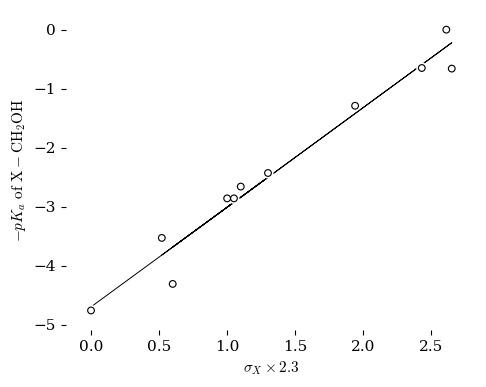

Acid Series (open circles)
slope  = 1.7
intercept = -4.699
RSQ = 0.965
LinregressResult(slope=1.6895937667680203, intercept=-4.699256841352174, rvalue=0.9824059118477302, pvalue=7.254178949850142e-08, stderr=0.10706554956339746, intercept_stderr=0.17424822877276588)


In [16]:
#####################################################
### Get series of data to plot from the dataframe ###
#####################################################

table_data_df2 = table_data_df.copy()
#table_data_df2.dropna(inplace = True)
print(table_data_df2)

y = -table_data_df2["pKa_COOH"]
x =  table_data_df2["sigma*"]

from scipy.stats import linregress
import matplotlib

##################################################
### Setup a figure with two plots side-by-side ###
### and choose a stylesheet                    ###
##################################################

style_file = "tufte.mplstyle"
plt.style.use(style_file)        

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   


#########################################
### Plot the data and the line fit.   ###
#########################################

#ax.plot(x, y, color='black', zorder=1, linewidth=0.7)

ax.scatter(x,y, s=64, color="white",  edgecolors = "none", zorder=2)
ax.scatter(x,y, s=32, color="black",  edgecolors = "none", zorder=2)
ax.scatter(x,y, s=16, color="white",  edgecolors = "none", alpha = 1, zorder=2)


if True:   # Flag to run or not. True = run this section, False = skip it
    linfit = linregress(x,y)
    fit = linfit.slope * x + linfit.intercept
    ax.plot(x, fit, color='black', zorder=1, linewidth=0.7)
    



############################
### Set labels and scale ###
############################

ax.set(
#    title="Hammett Plot",       
          ylabel=r"$-pK_a \rm~of~X-CH_2OH$", 
          xlabel=r"$\sigma_X \times 2.3$",                
#          xlim=[-.9,.9],                  
#          ylim=[-6,-1]
         )



if False:    # Flag to run or not. True = run this section, False = skip it
    for name,x_place,y_place in zip(list(df.index),x,y):
        plt.annotate(name, # this is the text
                    (x_place,y_place), # these are the coordinates to position the label
                    textcoords="offset points", # how to position the text
                    xytext=(30,0), # distance from text to points (x,y)
                    ha='left') # horizontal alignment can be left, right or center




fig.savefig("plots/plot3.pdf")   # use this to save the figure in PDF format
plt.show()                 # output the combined plot plots

#make_axes_area_auto_adjustable(ax)
#####################################
### Print the line fit parameters ###
#####################################
print("Acid Series (open circles)")
print(f"slope  = {linfit.slope:0.1f}")
print(f"intercept = {linfit.intercept:0.3f}")
print(f"RSQ = {(linfit.rvalue**2):0.3f}")
print(linfit)